<a href="https://colab.research.google.com/github/paulacca467/pub_selci/blob/main/secoestransversais_gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

# =============================================================================
# 1. FUNÇÕES AUXILIARES
# =============================================================================

def sw_dist(lat, lon, units='km'):
    R = 6371.0
    lat = np.radians(lat)
    lon = np.radians(lon)
    dlat = np.diff(lat)
    dlon = np.diff(lon)
    a = np.sin(dlat / 2)**2 + np.cos(lat[:-1]) * np.cos(lat[1:]) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    dist = R * c
    if units == 'm': dist *= 1000

    y = np.sin(dlon) * np.cos(lat[1:])
    x = np.cos(lat[:-1]) * np.sin(lat[1:]) - np.sin(lat[:-1]) * np.cos(lat[1:]) * np.cos(dlon)
    angle = np.degrees(np.arctan2(y, x))
    angle = (angle + 360) % 360
    return dist, angle

def uv2intdir(u, v, decl_mag=0):
    mag = np.sqrt(u**2 + v**2)
    direcao_rad = np.arctan2(u, v)
    direcao = (np.degrees(direcao_rad) + 360) % 360
    direcao = (direcao + decl_mag + 360) % 360
    return mag, direcao

def intdir2uv(mag, direcao, decl_mag=0, ang_rot=0):
    angle_rad = np.radians(direcao - decl_mag - ang_rot)
    u = mag * np.sin(angle_rad)
    v = mag * np.cos(angle_rad)
    return u, v

def load_sontek_file(pathname, filename_base, ext):
    fpath = os.path.join(pathname, filename_base + ext)
    if os.path.exists(fpath):
        try:
            return pd.read_csv(fpath, sep=r"\s+", header=None).values
        except:
            return None
    return None

# =============================================================================
# 2. CONFIGURAÇÃO E CARREGAMENTO DE DADOS
# =============================================================================

locais = ['nextbasecananeia','desembocaduracananeia','transversal_estuary_iguape', 'valogrande'];
local = locais[2];
## Abrindo pastas e definindo profundidade das celulas do ADP, lat e long para plot:
if local  == 'nextbasecananeia':
	      pasta='/content/drive/MyDrive/PUB_SELCI/cananeia/campo_dezembro_2019/dados_ADCP/ADCP/ADCP_dados_selecionados/next_base_dados_selecionados/'
	      z_initial = np.arange(2,18);
	      latf = -25.016111
	      lonf =  -47.922711
if local  == 'desembocaduracananeia':
        pasta='/content/drive/MyDrive/PUB_SELCI/cananeia/campo_dezembro_2019/dados_ADCP/ADCP/ADCP_dados_selecionados/desembocadura_cananeia_dados_selecionados/'
        z_initial = np.arange(2,23);
        latf = -25.056857;
        lonf = -47.912767;
if local == 'transversal_estuary_iguape':
        pasta ='/content/drive/MyDrive/PUB_SELCI/cananeia/campo_dezembro_2019/dados_ADCP/ADCP/ADCP_dados_selecionados/transversal_estuary_dados_selecionados/';
        z_initial = np.arange(2,16);
        latf = -24.706237;
        lonf =  -47.543533;
if local == 'valogrande':
        pasta ='/content/drive/MyDrive/PUB_SELCI/cananeia/campo_dezembro_2019/dados_ADCP/ADCP/ADCP_dados_selecionados/river_valogrande_dados_selecionados/'
        z_initial = np.arange(2,9);
        latf = -24.714309
        lonf = -47.564286

decl_mag= -20.71;#Estuario de Cananeia Iguape dez/2019

plt.close('all')

invertidos = ['C251912171603',
              'C121912171029',
              'C131912171124',
              'C141912171216',
              'C151912171524',
              'C161912171636',
              'C171912171808',
              'C181912171935',
              'C191912172020',
              'C191912172151',
              'C311912181043',
              'C321912181120',
              'C331912181209',
              'C341912181247',
              'C351912181320',
              'C361912181454',
              'C371912181530',
              'C381912181604',
              'C391912181642',
              'C391912181721',
              'C391912181838',
              'C391912181920']

# Identifica pastas
if os.path.exists(pasta):
    subfolders = [f.name for f in os.scandir(pasta) if f.is_dir()]
    subfolders.sort()
else:
    subfolders = []
    print("Pasta não encontrada.")

# Lista para armazenar os dados processados de cada transecto
dados_para_plot = []

print("--- Carregando dados... ---")

for folder_name in subfolders:
    pathname = os.path.join(pasta, folder_name)
    print(f"Lendo: {folder_name}")

    # Carrega arquivos
    V = load_sontek_file(pathname, folder_name, '.spd')
    D = load_sontek_file(pathname, folder_name, '.dir')
    VE = load_sontek_file(pathname, folder_name, '.ve')
    VN = load_sontek_file(pathname, folder_name, '.vn')
    GPS = load_sontek_file(pathname, folder_name, '.gps')
    BTK = load_sontek_file(pathname, folder_name, '.btk')

    if any(x is None for x in [V, D, VE, VN, GPS, BTK]):
        continue

    # Transpor e Limpar
    Vrot, Drot, VErot, VNrot = V.T, D.T, VE.T, VN.T
    bad_val = 3276.7
    Vrot[Vrot >= bad_val] = np.nan
    VErot[VErot >= bad_val] = np.nan
    VNrot[VNrot >= bad_val] = np.nan

    # Cortes iniciais (semelhante ao original)
    bu, la = 0, 0
    ve, vn = VErot[bu:, la:], VNrot[bu:, la:]
    v_raw = Vrot[bu:, la:]

    # Correção Magnética
    mag, direcao = uv2intdir(ve, vn, decl_mag)

    # Profundidade e Distância
    GPS_LAT = GPS[:, [2, 5]]; GPS_LON = GPS[:, [3, 6]]
    GPS_LAT[0,0] = GPS_LAT[0,1]; GPS_LON[0,0] = GPS_LON[0,1]
    lat, lon = np.mean(GPS_LAT, axis=1), np.mean(GPS_LON, axis=1)

    dst, phaseangle_full = sw_dist(lat, lon, 'km')
    DST = np.cumsum(dst)
    X = np.concatenate(([0], DST))
    X = X[la:] # Ajuste de corte la

    # Profundidade Z
    MAX_DEPTH = 17
    z = np.arange(1, MAX_DEPTH + 1)

    # Rotação (Longitudinal/Transversal)
    phaseangle2 = np.nanmean(phaseangle_full[3:-1]) if len(phaseangle_full) > 5 else np.nanmean(phaseangle_full)
    ang_rot = phaseangle2 + 90
    urot, vrot = intdir2uv(mag, direcao, decl_mag=0, ang_rot=ang_rot)

    # Conversão cm/s -> m/s
    urot /= 100.0
    vrot /= 100.0

    # Ajuste de Dimensões (Corte para menor tamanho comum entre dados e eixos)
    rows_min = min(len(z), vrot.shape[0])
    cols_min = min(len(X), vrot.shape[1])

    data_v = vrot[:rows_min, :cols_min]
    data_u = urot[:rows_min, :cols_min]
    z_final = z[:rows_min]
    x_final = X[:cols_min]

    # ... dentro do loop for folder_name in subfolders: ...

    x_final = X[:cols_min]

    if folder_name in invertidos:
        x_final = np.max(x_final) - x_final

        urot = -urot
        vrot = -vrot

        idx_sort = np.argsort(x_final)
        x_final = x_final[idx_sort]
        urot = urot[:, idx_sort]
        vrot = vrot[:, idx_sort]

    # Agora o meshgrid usará os dados corrigidos
    data_v = vrot[:rows_min, :cols_min]
    data_u = urot[:rows_min, :cols_min]

    # Meshgrid para plotagem
    X_mesh, Z_mesh = np.meshgrid(x_final, -z_final)

    # Armazena dicionário com tudo necessário para plotar depois
    dados_para_plot.append({
        'name': folder_name,
        'X_mesh': X_mesh,
        'Z_mesh': Z_mesh,
        'v_paralela': data_v,      # vrot (Paralela)
        'u_perpendicular': data_u, # urot (Perpendicular)
        'max_dist': np.max(x_final)
    })

# =============================================================================
# 3. CÁLCULO DE LIMITES GLOBAIS (DINÂMICOS)
# =============================================================================

if not dados_para_plot:
    print("Nenhum dado válido para plotar.")
    exit()

print("--- Calculando limites globais... ---")

# Junta todos os dados em um array gigante temporário para achar min/max
all_v = np.concatenate([d['v_paralela'].flatten() for d in dados_para_plot])
all_u = np.concatenate([d['u_perpendicular'].flatten() for d in dados_para_plot])

# Define limites simétricos baseados no máximo absoluto (para o zero ficar no centro da cor)
# Ex: se o max for 0.8 e min for -1.2, o limite será [-1.2, 1.2]
max_abs_v = np.nanmax(np.abs(all_v))
max_abs_u = np.nanmax(np.abs(all_u))

# Arredonda para cima (ex: 1.23 -> 1.3) para ficar bonito
limit_v = np.ceil(max_abs_v * 10) / 10
limit_u = np.ceil(max_abs_u * 10) / 10

# Define levels para contourf
levels_v = np.linspace(-limit_v, limit_v, 50)
levels_u = np.linspace(-limit_u, limit_u, 50)

--- Carregando dados... ---
Lendo: C411912181101
Lendo: C421912181133
Lendo: C431912181223
Lendo: C441912181300
Lendo: C451912181340
Lendo: C461912181508
Lendo: C471912181546
Lendo: C481912181621
Lendo: C491912181705
Lendo: C491912181741
Lendo: C491912181855
Lendo: C491912181936
--- Calculando limites globais... ---


In [2]:
import datetime as dt

timestamps = []
for filename in subfolders:

    date_time_str = filename[-10:]
    datetime_obj = dt.datetime.strptime(date_time_str, '%y%m%d%H%M')
    timestamps.append(datetime_obj)

timestamp = timestamps


Gerando grid Paralela...
Salvando: Grid_Paralela.png
Processamento concluído.


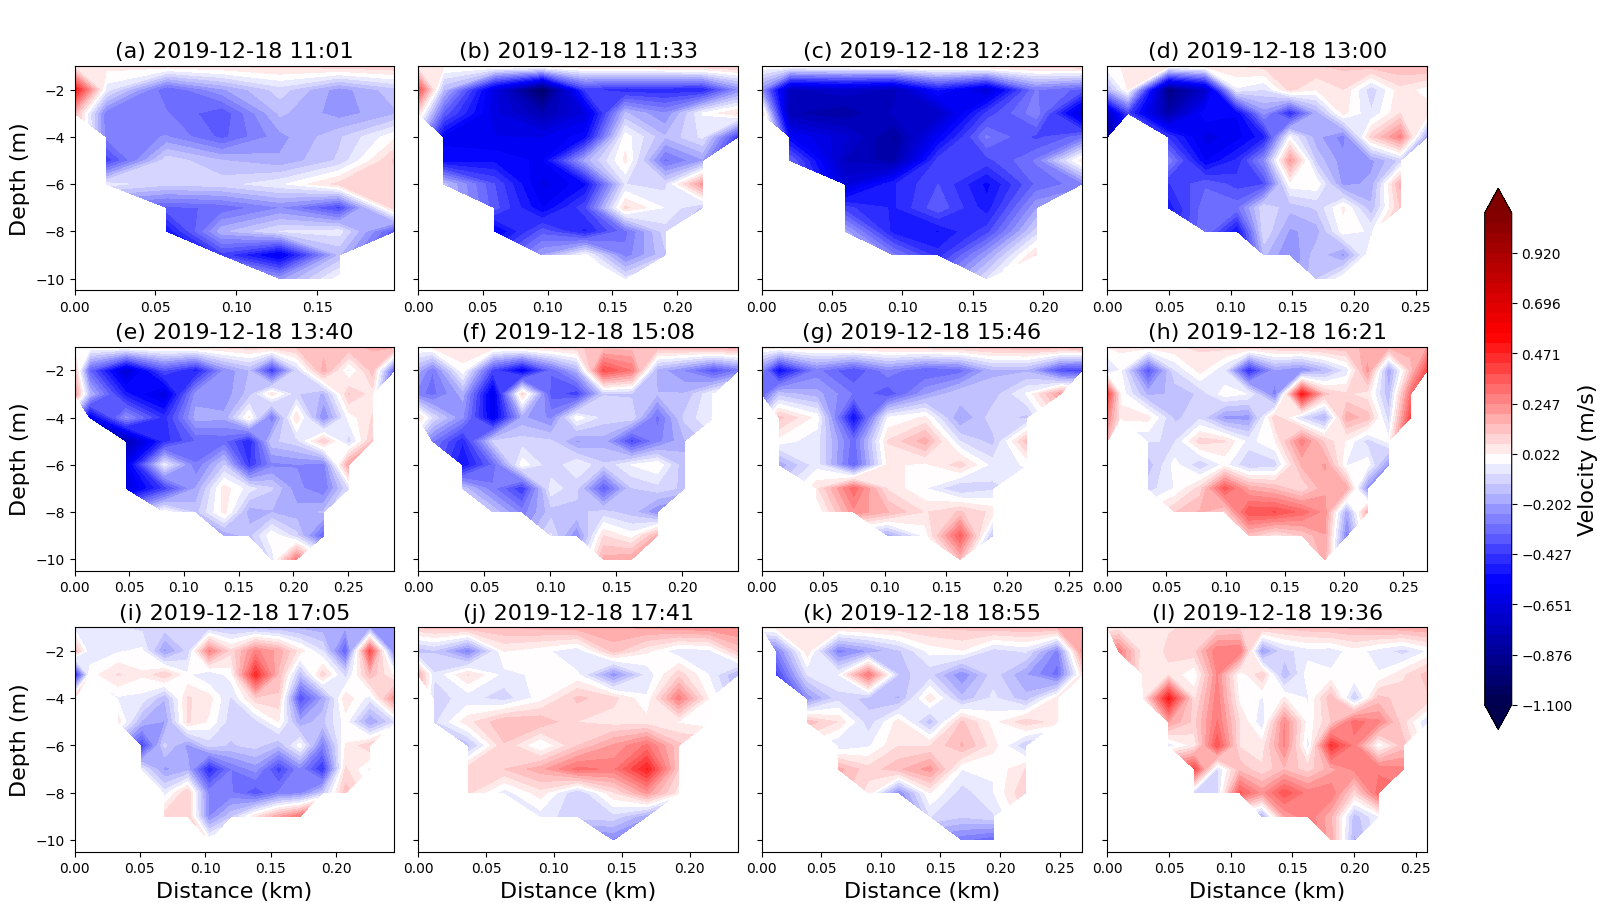

In [3]:
# =============================================================================
# 4. PLOTAGEM EM GRID
# =============================================================================

num_transects = len(dados_para_plot)
num_cols = int(np.ceil(np.sqrt(num_transects)))
num_rows = int(np.ceil(num_transects / num_cols))

def criar_grid_plot(tipo_dado, limit, levels, titulo_geral, filename_save, timestamps_list):
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols*4, num_rows*3), constrained_layout=True)
    axs = axs.flatten() # Transforma matriz de eixos em lista linear

    contour_img = None

    for i in range(len(axs)):
        ax = axs[i]

        if i < num_transects:
            dado = dados_para_plot[i]
            matrix = dado[tipo_dado] # 'v_paralela' ou 'u_perpendicular'


            # Plot
            contour_img = ax.contourf(dado['X_mesh'], dado['Z_mesh'], matrix,
                                      levels=levels, cmap='seismic', extend = 'both')

            # Only set title if timestamp exists
            if i < len(timestamps_list):
                plot_letter = chr(ord('a') + i)
                current_timestamp = timestamps_list[i]
                formatted_timestamp = current_timestamp.strftime('%Y-%m-%d %H:%M')
                ax.set_title(f"({plot_letter}) {formatted_timestamp}", fontsize=16)
            else:
                ax.set_title(dado['name'], fontsize=16)

            ax.set_ylim([-10.5, -1])
            #ax.set_xlim([-0.01, 0.16])

            # Só coloca labels nas bordas esquerdas e inferiores para limpar o visual
            if i % num_cols == 0:
                ax.set_ylabel('Depth (m)', fontsize = 16)
            else:
                ax.set_yticklabels([]) # Remove numeros Y

            # Labels X só na última linha (aproximadamente)
            if i >= num_transects - num_cols:
                ax.set_xlabel('Distance (km)', fontsize = 16)

        else:
            # Desliga eixos vazios se o grid for maior que o numero de plots
            ax.axis('off')

    # Barra de cores compartilhada
    if contour_img:
        cbar = fig.colorbar(contour_img, ax=axs, orientation='vertical', fraction=0.02, pad=0.04)
        cbar.set_label('Velocity (m/s)', fontsize = 16)

    fig.suptitle(titulo_geral, fontsize=18)

    print(f"Salvando: {filename_save}")
    plt.savefig(os.path.join(pasta, filename_save), dpi=300)

# --- Gerar Grid 1: Corrente Paralela ---
print("Gerando grid Paralela...")
criar_grid_plot('v_paralela', limit_v, levels_v,
                ' ', 'Grid_Paralela.png', timestamp)
plt.savefig(('grid_pararela_' + local + '.png'), dpi=300)



print("Processamento concluído.")

In [4]:
local

'transversal_estuary_iguape'

In [5]:
#!zip transversaisgrande.zip *.png

In [6]:
import numpy as np

# Velocidade Paralela
min_v_paralela = np.nanmin(all_v)
max_v_paralela = np.nanmax(all_v)

print(f"Menor velocidade paralela registrada: {min_v_paralela:.3f} m/s")
print(f"Maior velocidade paralela registrada: {max_v_paralela:.3f} m/s")

Menor velocidade paralela registrada: -1.022 m/s
Maior velocidade paralela registrada: 0.510 m/s
